# PROJECT 1  by Szymon Waliczek
# Introduction
- the topic is how the quantization resulting from confinement affects electron transport
- the role of confinement will be filled by an electrostatic potential sequencially: parabolic, scattering centers with Guassian distribution.
- **Note !!!**
- In our tight-binding square lattice with:
In a square lattice with **nearest-neighbor hopping** of $-t$ and an **on-site potential** of $4t$, the energy dispersion relation for electrons is given by:
$$
E(k_x, k_y) = 4t - 2t \cos(k_x a) - 2t \cos(k_y a)
$$
where $k_x, k_y \in [0, \pi/a]$. This relation describes how the energy of an electron depends on its wavevector components in the $x$ and $y$ directions.
The resulting energy band spans the range:
$$
E \in [0, 8t]
$$
This defines the **allowed energy states (band structure)** for the system.

# Librarys
- Import the needed librarys / constants

In [162]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as scp

# Physical parameters 
- necessary to model this kind of phenomena
- we can either operate on unrealistic but inuitive and easy to operate values with real units
- or we can use experimental values wich significantly would take more time

In [163]:
# --- Parametry fizyczne ---
a = 1.0  # stała sieciowa
t = 1.0  # parametr skokowy (hopping) t = h_bar^2/(2ma^2)             To było podejście modelowe, uproszczone —   
sys_width = 80 # assumingly in nm               # szybkie do uruchomienia i wizualizacji, ale nie ma ono fizycznego
sys_length = 80                                 # odniesienia bez przeliczeń. Jest ono często używane na wstępnym etapie
                                                # (tight-binding model), ale nie odpowiada pełni projektu, który Ty realizujesz.

#from scp import physical_constants as phy
# --- Jednostki i stałe ---
#eV = phy['electron volt'][0]  # [J]
#hbar = phy['Planck constant over 2 pi'][0]  # [J*s]
#m0 = phy['electron mass'][0]  # [kg]
#m_eff = 0.067 * m0  # efektywna masa w GaAs
#a = 1e-9  # nm → m
#t = hbar**2 / (2 * m_eff * a**2) / eV  # w jednostkach eV

# Shape of our system
- universal for all the variants we're gonna discuss
- for now electrons roughly have only kinetic energy

- now using kwant we create the system 
- we assign to every matrix element corresponding to every crossing point on the lattice values of the actual states - meaning eventual additional potential
- also we add the leads which are crucial for "injecting" electrons inside the "square" and defining boundary conditions for theire wavefunctions
- How the below code corresponds directly to the terms of the discretized Hamiltonian:
1) Onsite:

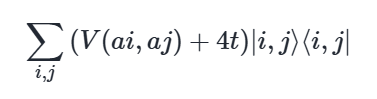

2) Hopping in x-direction:

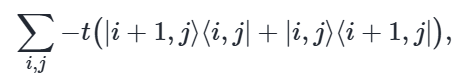

3) Hopping in y-directrion

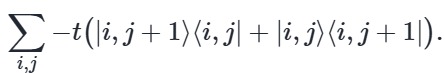

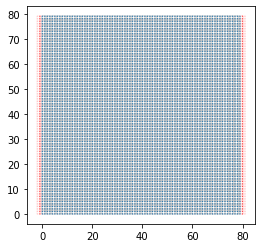

In [164]:
sys = kwant.Builder()
lat = kwant.lattice.square(a, norbs=1)

# Define the scattering region
sys[(lat(x, y) for x in range(sys_length) for y in range(sys_width))] = 4 * t
sys[lat.neighbors()] = -t

lead = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
lead[(lat(0, y) for y in range(sys_width))] = 4 * t
lead[lat.neighbors()] = -t

sys.attach_lead(lead)
sys.attach_lead(lead.reversed())

kwant.plot(sys);

In [166]:
# --- Finalizacja systemu konieczna do jego użycia ---
fsys = sys.finalized()

- now we must define how thorough we want our simmulations to be but we can't go to far since then the calculesions will take huge memory
- so we define the energies we want to calculate

In [255]:
energies_try = []
transmission_try = []
for i in range(100):
    energy_try = i * 0.08
    smatrix_try = kwant.smatrix(fsys, energy_try)
    energies_try.append(energy_try)
    transmission_try.append(smatrix_try.transmission(1, 0))

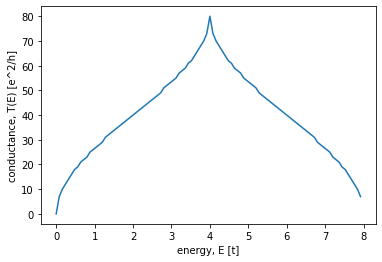

In [257]:
plt.figure()
plt.plot(energies_try, transmission_try)
plt.xlabel("energy, E [t]")
plt.ylabel("conductance, T(E) [e^2/h]")
plt.show()

In [248]:
energies = []
transmission = []
for i in range(200):
    energy = i * 0.005
    smatrix = kwant.smatrix(fsys, energy)
    energies.append(energy)
    transmission.append(smatrix.transmission(1, 0))

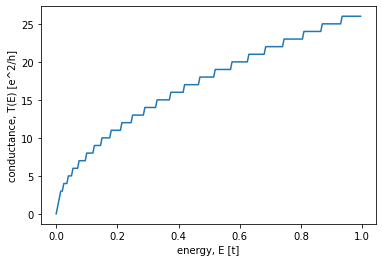

In [249]:
plt.figure()
plt.plot(energies, transmission)
plt.xlabel("energy, E [t]")
plt.ylabel("conductance, T(E) [e^2/h]")
plt.show()

### Conclusion
Using the full energy band [0,8t] in a square lattice system causes all 80 modes to eventually contribute, which results in a very smooth and high conductance curve, resembling a "symmetric mountain". This makes it hard to see the quantized conductance steps that are characteristic of mode opening in a waveguide.
- Therefore we are goin to stick to the energy values from 0 to 1t
### Why does the conductance reach values up to 80?
In our Kwant simulation, the conductance values are calculated using the **Landauer formula**, where each propagating mode (channel) in the lead contributes a quantum of conductance:
\[
G = T(E) \cdot \frac{e^2}{h}
\]
Here, \( T(E) \) is the total transmission at energy \( E \), and each mode ideally contributes \$( 1 \cdot \frac{e^2}{h} $\).
In this system, the width is set to `sys_width = 80`, which defines the number of lattice sites (and thus the number of transverse modes) in the lead. At high enough energy, all 80 modes can be occupied, leading to a **maximum transmission** of \( T(E) = 80 \), which corresponds to **maximum conductance of 80 \( e^2/h \)**.
So, the plot above reaching values near 80 is correct and expected—it simply means all 80 channels are contributing to conduction at high energy.
This transmission spectrum shows quantized conductance steps due to the opening of discrete transverse modes in the waveguide. The steps correspond to the available energy levels without any external potential applied.
- A quantum conductance staircase — each step = 1 conduction mode opening.
- In our 2D waveguide (the square region with leads), as energy increases more transverse modes become available.
- Each new mode contributes a quantized amount to transmission:
    ΔT=1(in units of e^2/h)
- So transmission goes like:
    T(E)=Number of open modes at energy E
- Each mode has an energy threshold:
    𝐸𝑛=𝐸kin+𝐸𝑛, Where 
    𝐸𝑛∝(𝑛𝜋𝑊)2 is the transverse quantization energy.
- So to open the n-th mode, you need:
    𝐸≥𝑛2𝜋22𝑚𝑊2
- In our tight-binding model (with t=1,a=1), the number of modes 
    𝑁(𝐸)∝𝐸, because number of open modes≈𝑊𝜋2𝑚𝐸⇒𝑇(𝐸)∼𝐸 
- This gives :
    A stepwise increasing function, but the step locations follow a square root law.

# + Parabolic potential U_par
-First we define parabolic potential and plot it to be sure it is correct
-  """
    Parabolic potential function.
    - Accepts either a `site` object (from Kwant) or a numeric y value.
    - Returns U(y) = U0 * ((y - y0) / y0)^2 + 4t
    """

In [233]:
 # Parabolic potential along OY axis
def U_par(y_or_site, U0=1.0):
    y0 = sys_width / 2.0
    if hasattr(y_or_site, 'pos'):
        # Called from Kwant: extract y from site.pos
        _, y = y_or_site.pos
    else:
        # Called with plain y value (e.g. for plotting)
        y = y_or_site
    return 4 * t + U0 * ((y - y0) / y0)**2

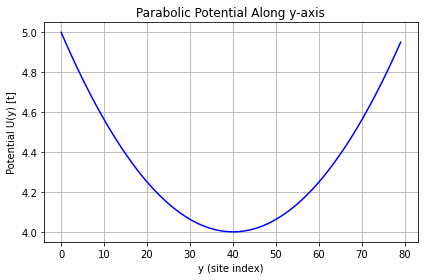

In [234]:
# --- Evaluate potential over y range ---
y_vals = np.arange(sys_width)
U_vals = [U_par(y) for y in y_vals]

# --- Plot the potential ---
plt.figure(figsize=(6, 4))
plt.plot(y_vals, U_vals, color='blue')
plt.title("Parabolic Potential Along y-axis")
plt.xlabel("y (site index)")
plt.ylabel("Potential U(y) [t]")
plt.grid(True)
plt.tight_layout()
plt.show()

- now we create a new system baised on the previous one but with the parabolic potential

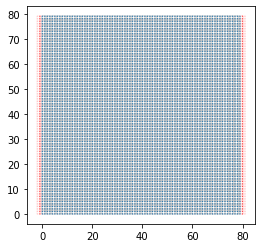

In [235]:
sys_par = kwant.Builder()
lat_par = kwant.lattice.square(a, norbs=1)
sys_par[(lat_par(x, y) for x in range(sys_length) for y in range(sys_width))] = U_par

# Define the scattering region
sys_par[lat_par.neighbors()] = -t

lead_par = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
lead_par[(lat_par(0, j) for j in range(sys_width))] = 4 * t
lead_par[lat_par.neighbors()] = -t

sys_par.attach_lead(lead_par) # left lead
sys_par.attach_lead(lead_par.reversed()) # right lead

kwant.plot(sys_par);

In [236]:
fsys_par = sys_par.finalized()

- we assign energy values and calculate transmission

In [258]:
energies_par = []
transmission_par = []
for i in range(200):
    energy_par = i * 0.005
    smatrix_par = kwant.smatrix(fsys_par, energy_par)
    energies_par.append(energy_par)
    transmission_par.append(smatrix_par.transmission(1, 0))

- and we plot our transmission

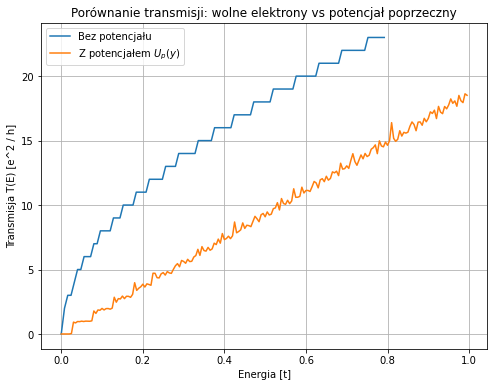

In [259]:
# Wykres porównawczy 1
plt.figure(figsize=(8, 6))
plt.plot(energies, transmission, label="Bez potencjału")
plt.plot(energies_par, transmission_par, label="Z potencjałem $U_p(y)$")
plt.xlabel("Energia [t]")
plt.ylabel("Transmisja T(E) [e^2 / h]")
plt.title("Porównanie transmisji: wolne elektrony vs potencjał poprzeczny")
plt.legend()
plt.grid(True)
plt.show()

### Conclusion
 - The parabolic potential confines electrons along the y-axis, increasing the effective energy separation between modes. This causes a shift in transmission steps and suppresses conductance at low energies.

# Conductance Behavior in a Quantum System

## 1. Free Electrons (No Transverse Potential)
- Transmission increases in **discrete steps** with energy.
- Each new **transverse mode** (channel) opens at a specific energy threshold.
- In an ideal ballistic system:
  
  $$
  T(E) = N, \quad \text{where } N = \text{number of open modes}
  $$

- In natural units, each mode contributes:
  
  $$
  \frac{e^2}{h} \rightarrow 1
  $$

---

## 2. With a Transverse Potential (e.g., Parabolic)
- Transmission still exhibits **step-like** behavior, but:
  - Steps are **shifted to higher energies**.
  - Steps may be **smoother or rounded**.
  - **Strong potential** can **suppress or distort** some modes.
  - In extreme cases, steps become hard to distinguish, forming a **quasi-linear increase with spikes**.

---

## Why Can It Look Almost Linear?

This visual effect can appear if:
- The transverse potential is **weak** (low $U_0$),
- The system is **wide** (`sys_width` is large → many modes),
- The **energy range is large**,
- The **plot scale is too coarse** to resolve individual steps.

Then, the **sum of many smooth steps** can **look like a straight line**,  
but it's **not truly linear** — it’s an effect of **mode accumulation and smoothing**.

---

In [177]:
def PSI(fsys, energy, title):
    wf = kwant.wave_function(fsys, energy)
    psi = wf(0)  # fala padająca z lewego leada
    psi_total = sum(np.abs(p)**2 for p in psi)

    coords = [site.pos for site in fsys.sites]
    x_coords, y_coords = zip(*coords)

    plt.figure(figsize=(6, 5))
    plt.tripcolor(x_coords, y_coords, psi_total, shading='gouraud', cmap='inferno')
    plt.xlabel("x [site index]")
    plt.ylabel("y [site index]")
    plt.title(title)
    plt.colorbar(label="|ψ|²")
    plt.tight_layout()
    plt.show()
    
def PSI_par(fsys_par, energy_par, title):
    wf = kwant.wave_function(fsys_par, energy_par)
    psi_par = wf(0)  # stan z lewego leada
    psi_total = sum(np.abs(p)**2 for p in psi_par)

    coords = [site.pos for site in fsys_par.sites]
    x_coords, y_coords = zip(*coords)
    plt.figure(figsize=(6, 5))
    plt.tripcolor(x_coords, y_coords, psi_total, shading='gouraud')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.colorbar(label="|ψ|²")
    plt.tight_layout()
    plt.show()

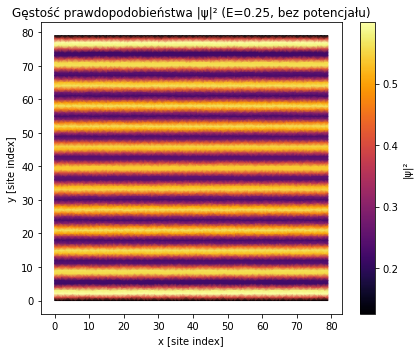

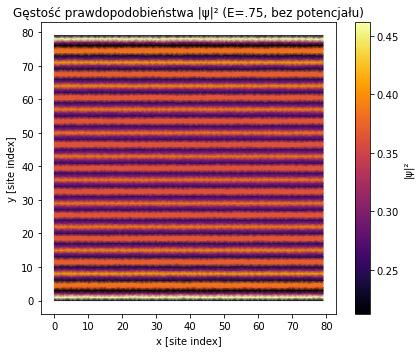

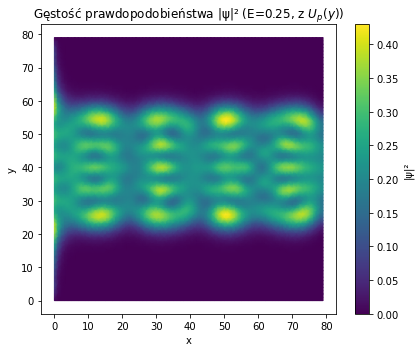

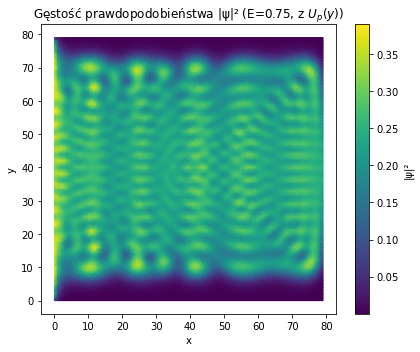

In [229]:
PSI(fsys, 0.25, "Gęstość prawdopodobieństwa |ψ|² (E=0.25, bez potencjału)")
PSI(fsys, 0.75, "Gęstość prawdopodobieństwa |ψ|² (E=.75, bez potencjału)")

PSI_par(fsys_par, 0.25, "Gęstość prawdopodobieństwa |ψ|² (E=0.25, z $U_p(y)$)")
PSI_par(fsys_par, 0.75, "Gęstość prawdopodobieństwa |ψ|² (E=0.75, z $U_p(y)$)")

### Probability Density Conclusions
- **U = 0**: Free propagation is evident with smooth mode structure.
- **Parabolic potential**: Clear confinement in the y-direction; central channeling of electron wavefunction.

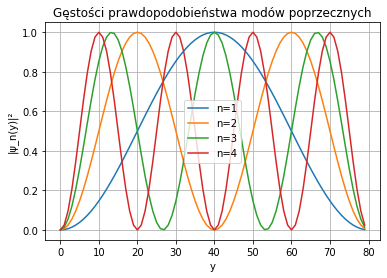

In [179]:
y_vals = np.linspace(0, sys_width-1, sys_width)
for n in range(1, 5):
    psi_n = np.sin(n * np.pi * y_vals / sys_width)
    plt.plot(y_vals, psi_n**2, label=f"n={n}")
plt.xlabel("y")
plt.ylabel("|ψ_n(y)|²")
plt.legend()
plt.title("Gęstości prawdopodobieństwa modów poprzecznych")
plt.grid(True)
plt.show()

# + Scattering Gaussian Center(s) Potential
- we define two centers one with positive maximal center value (atractive) and one with negative "minimal value" (repulsive for electrons)
-    Gaussian scattering potential centered in the system.
    - Accepts either a Kwant `site` object or a tuple (x, y) or separate numeric x, y.
    - Returns U(x, y) = A * exp(-((x - x0)^2 + (y - y0)^2) / (2 * sigma^2)) + 4t

In [180]:
def U1_gauss(x_or_site, y_or_site, A1 = -0.2, sigma = 5.0):
    x0 = sys_length / 2
    y0 = sys_width / 2
    if hasattr(x_or_site, 'pos'):
         # Called from Kwant: extract x from site.pos
        x, _ = x_or_site.pos
    if hasattr(y_or_site, 'pos'):
         # Called from Kwant: extract y from site.pos
        _, y = y_or_site.pos
    else:
        # Called with plain x, y value (e.g. for plotting)
        x = x_or_site
        y = y_or_site
    return 4*t + A1 * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))
#-----------------------------------------------------------------------------------------
def U2_gauss(x_or_site, y_or_site, A2 = 0.2, sigma = 5.0):
    x0 = sys_length / 2
    y0 = sys_width / 2
    if hasattr(x_or_site, 'pos'):
         # Called from Kwant: extract x from site.pos
        x, _ = x_or_site.pos
    if hasattr(y_or_site, 'pos'):
         # Called from Kwant: extract y from site.pos
        _, y = y_or_site.pos
    else:
        # Called with plain x, y value (e.g. for plotting)
        x = x_or_site
        y = y_or_site
    return 4*t + A2 * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))

- Now we plot both centers to insure correctness
- Note U = 4.0 corresponds to 0.0  !!

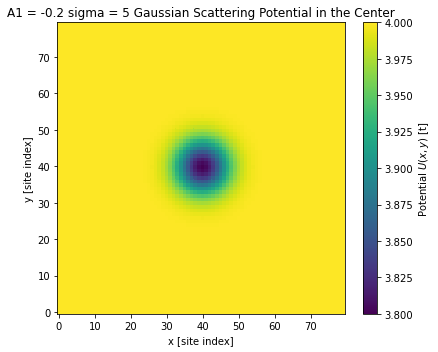

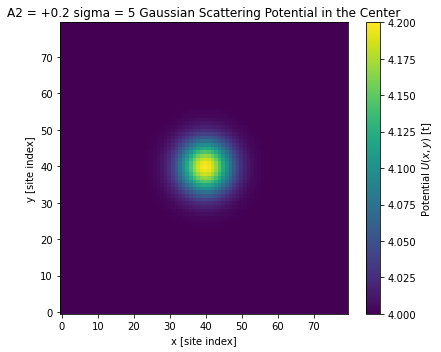

In [181]:
# Create grid
x_vals = np.arange(sys_length)
y_vals = np.arange(sys_width)
X, Y = np.meshgrid(x_vals, y_vals, indexing='ij')
U1_vals = U1_gauss(X, Y)
U2_vals = U2_gauss(X, Y)

# Plot potential U1_gauss
plt.figure(figsize=(6, 5))
plt.pcolormesh(X, Y, U1_vals, shading='auto', cmap='viridis')
plt.colorbar(label='Potential $U(x, y)$ [t]')
plt.title('A1 = -0.2 sigma = 5 Gaussian Scattering Potential in the Center')
plt.xlabel('x [site index]')
plt.ylabel('y [site index]')
plt.tight_layout()
plt.show()
#----------------------------------------------------------------------------------
# Plot potential U2_gauss
plt.figure(figsize=(6, 5))
plt.pcolormesh(X, Y, U2_vals, shading='auto', cmap='viridis')
plt.colorbar(label='Potential $U(x, y)$ [t]')
plt.title('A2 = +0.2 sigma = 5 Gaussian Scattering Potential in the Center')
plt.xlabel('x [site index]')
plt.ylabel('y [site index]')
plt.tight_layout()
plt.show()

- now we create 2 systems for each potential alone

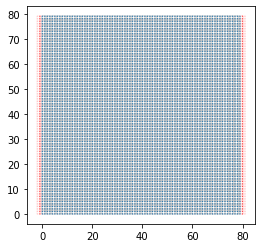

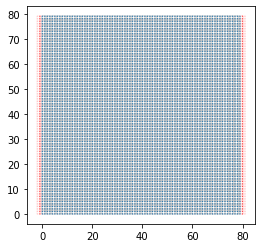

In [182]:
# Lattice
lat1_gauss = kwant.lattice.square(a, norbs=1)
# Scattering region
sys1_gauss = kwant.Builder()
sys1_gauss[(lat1_gauss(x, y) for x in range(sys_length) for y in range(sys_width))] = \
    lambda site: U1_gauss(site, site, A1=-0.2, sigma=5.0)

sys1_gauss[lat1_gauss.neighbors()] = -t

# Leads
lead1_gauss = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
lead1_gauss[(lat(0, y) for y in range(sys_width))] = 4 * t
lead1_gauss[lat1_gauss.neighbors()] = -t

sys1_gauss.attach_lead(lead1_gauss) # left lead
sys1_gauss.attach_lead(lead1_gauss.reversed()) # right lead

kwant.plot(sys1_gauss);
#--------------------------------------------------------------------------------------------------
# Lattice
lat2_gauss = kwant.lattice.square(a, norbs=1)
# Scattering region
sys2_gauss = kwant.Builder()
sys2_gauss[(lat2_gauss(x, y) for x in range(sys_length) for y in range(sys_width))] = \
    lambda site: U2_gauss(site, site, A2 = +0.2, sigma = 5.0)

sys2_gauss[lat2_gauss.neighbors()] = -t

# Leads
lead2_gauss = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
lead2_gauss[(lat(0, y) for y in range(sys_width))] = 4 * t
lead2_gauss[lat2_gauss.neighbors()] = -t

sys2_gauss.attach_lead(lead2_gauss) # left lead
sys2_gauss.attach_lead(lead2_gauss.reversed()) # right lead

kwant.plot(sys2_gauss);

In [183]:
# Finalize
fsys1_gauss = sys1_gauss.finalized()
fsys2_gauss = sys2_gauss.finalized()

In [184]:
# Compute transmission U1
energies1_gauss = []
transmissions1_gauss = []
for i in range(200):
    energy1_gauss = i * 0.005
    smatrix1_gauss = kwant.smatrix(fsys1_gauss, energy1_gauss)
    energies1_gauss.append(energy1_gauss)
    transmissions1_gauss.append(smatrix1_gauss.transmission(1, 0))

In [185]:
# Compute transmission U2
energies2_gauss = []
transmissions2_gauss = []
for i in range(200):
    energy2_gauss = i * 0.005
    smatrix2_gauss = kwant.smatrix(fsys2_gauss, energy2_gauss)
    energies2_gauss.append(energy2_gauss)
    transmissions2_gauss.append(smatrix2_gauss.transmission(1, 0))

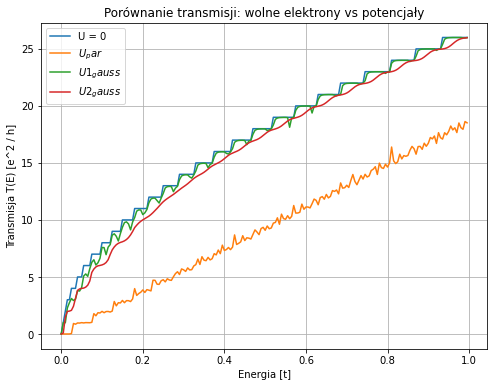

In [186]:
# Wykres porównawczy 2
plt.figure(figsize=(8, 6))
plt.plot(energies, transmission, label="U = 0")
plt.plot(energies_par, transmission_par, label="$U_par$")
plt.plot(energies1_gauss, transmissions1_gauss, label="$U1_gauss$")
plt.plot(energies2_gauss, transmissions2_gauss, label="$U2_gauss$")
plt.xlabel("Energia [t]")
plt.ylabel("Transmisja T(E) [e^2 / h]")
plt.title("Porównanie transmisji: wolne elektrony vs potencjały")
plt.legend()
plt.grid(True)
plt.show()

### Conclusion
- $U1_{gauss}$ (attractive): Localized potential well leads to resonant tunneling, visible as oscillations in transmission.
- $U2_{gauss}$ (repulsive): Causes partial blocking at low energy due to a barrier in the center.
- $U3_{gauss}$ (superposed): Complex potential landscape with multiple scattering centers leads to strong interference effects and irregular transmission behavior.

- Now we calculate and plot conduction/density of probability

In [200]:
def PSI1_gauss(fsys1_gauss, energy1_gauss, title):
    wf1_gauss = kwant.wave_function(fsys1_gauss, energy1_gauss)
    psi1_gauss = wf1_gauss(0)  # fala padająca z lewego leada
    psi_total = sum(np.abs(p)**2 for p in psi1_gauss)

    coords = [site.pos for site in fsys1_gauss.sites]
    x_coords, y_coords = zip(*coords)

    plt.figure(figsize=(6, 5))
    plt.tripcolor(x_coords, y_coords, psi_total, shading='gouraud',)
    plt.xlabel("x [site index]")
    plt.ylabel("y [site index]")
    plt.title(title)
    plt.colorbar(label="|ψ|²")
    plt.tight_layout()
    plt.show()
    
def PSI2_gauss(fsys2_gauss, energy2_gauss, title):
    wf2_gauss = kwant.wave_function(fsys2_gauss, energy2_gauss)
    psi2_gauss = wf2_gauss(0)  # fala padająca z lewego leada
    psi_total = sum(np.abs(p)**2 for p in psi2_gauss)

    coords = [site.pos for site in fsys2_gauss.sites]
    x_coords, y_coords = zip(*coords)

    plt.figure(figsize=(6, 5))
    plt.tripcolor(x_coords, y_coords, psi_total, shading='gouraud', cmap='inferno')
    plt.xlabel("x [site index]")
    plt.ylabel("y [site index]")
    plt.title(title)
    plt.colorbar(label="|ψ|²")
    plt.tight_layout()
    plt.show()

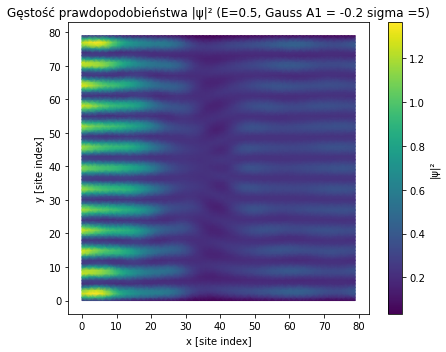

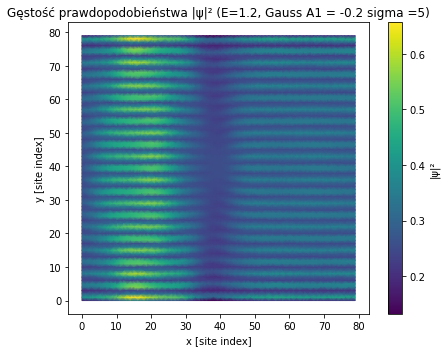

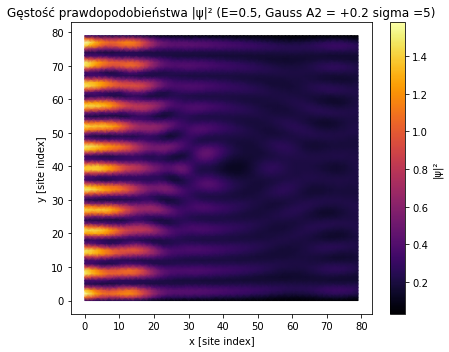

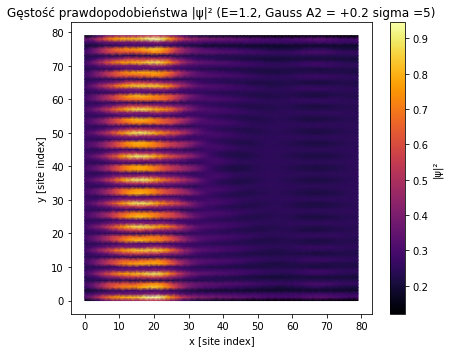

In [201]:
PSI1_gauss(fsys1_gauss, 0.25, "Gęstość prawdopodobieństwa |ψ|² (E=0.5, Gauss A1 = -0.2 sigma =5)")
PSI1_gauss(fsys1_gauss, 0.75, "Gęstość prawdopodobieństwa |ψ|² (E=1.2, Gauss A1 = -0.2 sigma =5)")

PSI2_gauss(fsys2_gauss, 0.25, "Gęstość prawdopodobieństwa |ψ|² (E=0.5, Gauss A2 = +0.2 sigma =5)")
PSI2_gauss(fsys2_gauss, 0.75, "Gęstość prawdopodobieństwa |ψ|² (E=1.2, Gauss A2 = +0.2 sigma =5)")

### Probability Density Conclusions
- **$U1_{gauss}$ (attractive)**: Local density peaks at the center reflect wavefunction trapping.
- **$U2_{gauss}$ (repulsive)**: Wavefunction avoids central region; wavefront splitting observed.

# + Superposition of two scattering Gaussian centers

In [222]:
def U3_gauss(x_or_site, y_or_site, A1 = +0.2, A2 = -0.4, sigma1 = 15.0, sigma2 = 5.0):
    x0 = sys_length / 2
    y0 = sys_width / 2
    if hasattr(x_or_site, 'pos'):
         # Called from Kwant: extract x from site.pos
        x, _ = x_or_site.pos
    if hasattr(y_or_site, 'pos'):
         # Called from Kwant: extract y from site.pos
        _, y = y_or_site.pos
    else:
        # Called with plain x, y value (e.g. for plotting)
        x = x_or_site
        y = y_or_site
    return 4*t + A1*np.exp(-((x - x0)**2 + (y - y0)**2) / (2*sigma1**2)) +\
A2*np.exp(-((x - x0)**2 + (y - y0)**2) / (2*sigma2**2))

- we plot potetntial

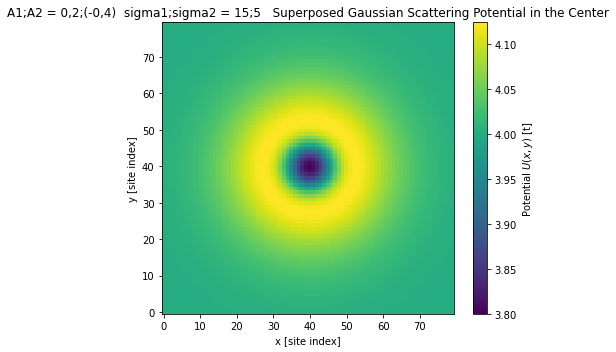

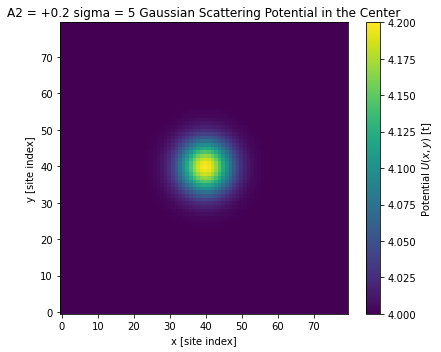

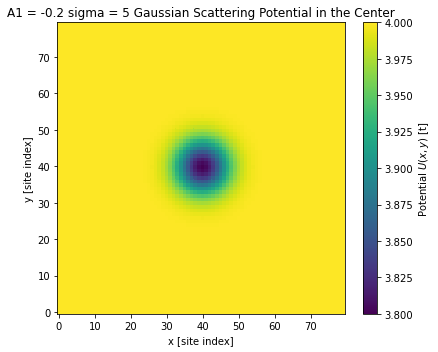

In [191]:
# Create grid
x_vals = np.arange(sys_length)
y_vals = np.arange(sys_width)
X, Y = np.meshgrid(x_vals, y_vals, indexing='ij')
U3_vals = U3_gauss(X, Y)
U1_vals = U1_gauss(X, Y)
U2_vals = U2_gauss(X, Y)

# Plot potential U3_gauss
plt.figure(figsize=(6, 5))
plt.pcolormesh(X, Y, U3_vals, shading='auto', cmap='viridis')
plt.colorbar(label='Potential $U(x, y)$ [t]')
plt.title('A1;A2 = 0,2;(-0,4)  sigma1;sigma2 = 15;5   Superposed Gaussian Scattering Potential in the Center')
plt.xlabel('x [site index]')
plt.ylabel('y [site index]')
plt.tight_layout()
plt.show()

# Plot potential U2_gauss
plt.figure(figsize=(6, 5))
plt.pcolormesh(X, Y, U2_vals, shading='auto', cmap='viridis')
plt.colorbar(label='Potential $U(x, y)$ [t]')
plt.title('A2 = +0.2 sigma = 5 Gaussian Scattering Potential in the Center')
plt.xlabel('x [site index]')
plt.ylabel('y [site index]')
plt.tight_layout()
plt.show()

# Plot potential U1_gauss
plt.figure(figsize=(6, 5))
plt.pcolormesh(X, Y, U1_vals, shading='auto', cmap='viridis')
plt.colorbar(label='Potential $U(x, y)$ [t]')
plt.title('A1 = -0.2 sigma = 5 Gaussian Scattering Potential in the Center')
plt.xlabel('x [site index]')
plt.ylabel('y [site index]')
plt.tight_layout()
plt.show()

- now we create a system with the potential of superposed two gaussian functions with different amplitudes and std_div.

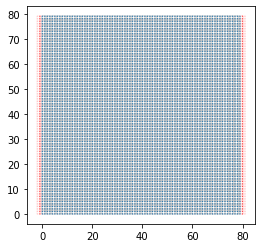

In [192]:
# Lattice
lat3_gauss = kwant.lattice.square(a, norbs=1)
# Scattering region
sys3_gauss = kwant.Builder()
sys3_gauss[(lat3_gauss(x, y) for x in range(sys_length) for y in range(sys_width))] = \
    lambda site: U3_gauss(site, site, A1 = +0.2, A2 = -0.4, sigma1 = 15.0, sigma2 = 5.0)

sys3_gauss[lat3_gauss.neighbors()] = -t

# Leads
lead3_gauss = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
lead3_gauss[(lat(0, y) for y in range(sys_width))] = 4 * t
lead3_gauss[lat3_gauss.neighbors()] = -t

sys3_gauss.attach_lead(lead3_gauss) # left lead
sys3_gauss.attach_lead(lead3_gauss.reversed()) # right lead

kwant.plot(sys3_gauss);

In [193]:
fsys3_gauss = sys3_gauss.finalized()

In [194]:
# Compute transmission U3
energies3_gauss = []
transmissions3_gauss = []
for i in range(200):
    energy3_gauss = i * 0.005
    smatrix3_gauss = kwant.smatrix(fsys3_gauss, energy3_gauss)
    energies3_gauss.append(energy3_gauss)
    transmissions3_gauss.append(smatrix3_gauss.transmission(1, 0))

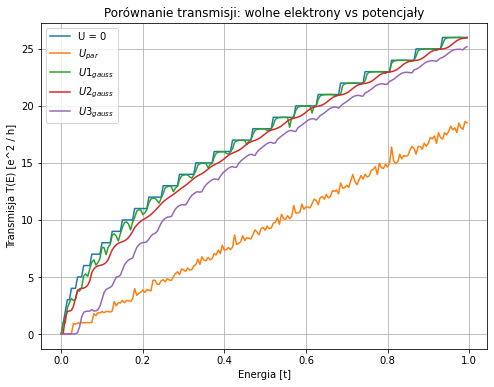

In [212]:
# Wykres porównawczy 3
plt.figure(figsize=(8, 6))
plt.plot(energies, transmission, label="U = 0")
plt.plot(energies_par, transmission_par, label="$U_{par}$")
plt.plot(energies1_gauss, transmissions1_gauss, label="$U1_{gauss}$")
plt.plot(energies2_gauss, transmissions2_gauss, label="$U2_{gauss}$")
plt.plot(energies3_gauss, transmissions3_gauss, label="$U3_{gauss}$")
plt.xlabel("Energia [t]")
plt.ylabel("Transmisja T(E) [e^2 / h]")
plt.title("Porównanie transmisji: wolne elektrony vs potencjały")
plt.legend()
plt.grid(True)
plt.show()

### Conclusion
- $U3_{gauss}$ (superposed): Complex potential landscape with multiple scattering centers leads to strong interference effects and irregular transmission behavior.

In [203]:
def PSI3_gauss(fsys3_gauss, energy3_gauss, title):
    wf3_gauss = kwant.wave_function(fsys3_gauss, energy3_gauss)
    psi3_gauss = wf3_gauss(0)  # fala padająca z lewego leada
    psi_total = sum(np.abs(p)**2 for p in psi3_gauss)

    coords = [site.pos for site in fsys3_gauss.sites]
    x_coords, y_coords = zip(*coords)

    plt.figure(figsize=(6, 5))
    plt.tripcolor(x_coords, y_coords, psi_total, shading='gouraud',)
    plt.xlabel("x [site index]")
    plt.ylabel("y [site index]")
    plt.title(title)
    plt.colorbar(label="|ψ|²")
    plt.tight_layout()
    plt.show()

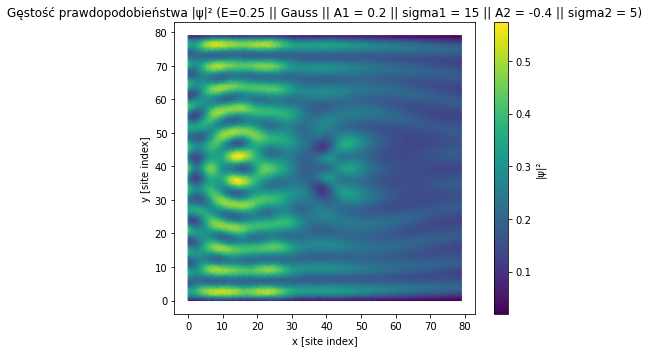

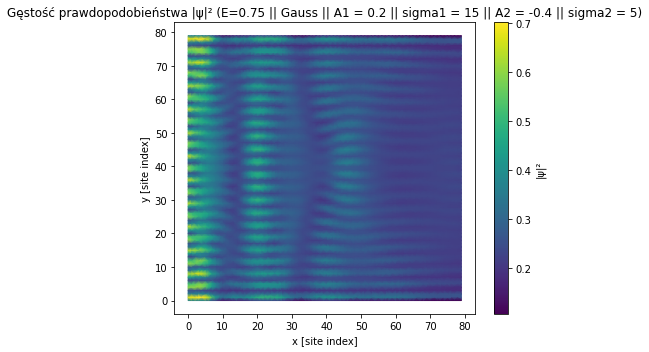

In [226]:
PSI3_gauss(fsys3_gauss, 0.25, "Gęstość prawdopodobieństwa |ψ|² (E=0.25 || Gauss || A1 = 0.2 || sigma1 = 15 || A2 = -0.4 || sigma2 = 5)")
PSI3_gauss(fsys3_gauss, 0.75, "Gęstość prawdopodobieństwa |ψ|² (E=0.75 || Gauss || A1 = 0.2 || sigma1 = 15 || A2 = -0.4 || sigma2 = 5)")

### Probability Density Conclusions
- **$U3_{gauss}$ (dual Gaussian)**: Complex interference between potential well and barrier causes mixed localized/delocalized states.

# + now several (4) scattering Gaussian centers with A = 0.2 and simga = 4

In [215]:
def U4_gauss(x_or_site, y_or_site, A = 0.2, sigma = 4.0):
    x1 = sys_length / 4
    y1 = sys_width / 4
    x2 = 3 * sys_length / 4
    y2 = sys_width / 4
    x3 = 3 * sys_length / 4
    y3 = 3 * sys_width / 4
    x4 = sys_length / 4
    y4 = 3 * sys_width / 4
    
    if hasattr(x_or_site, 'pos'):
         # Called from Kwant: extract x from site.pos
        x, _ = x_or_site.pos
    if hasattr(y_or_site, 'pos'):
         # Called from Kwant: extract y from site.pos
        _, y = y_or_site.pos
    else:
        # Called with plain x, y value (e.g. for plotting)
        x = x_or_site
        y = y_or_site
    return 4*t + A*np.exp(-((x - x1)**2 + (y - y1)**2) / (2*sigma**2)) + A*np.exp(-((x - x2)**2 + (y - y2)**2) / (2*sigma**2)) +\
A*np.exp(-((x - x3)**2 + (y - y3)**2) / (2*sigma**2)) + A*np.exp(-((x - x4)**2 + (y - y4)**2) / (2*sigma**2))

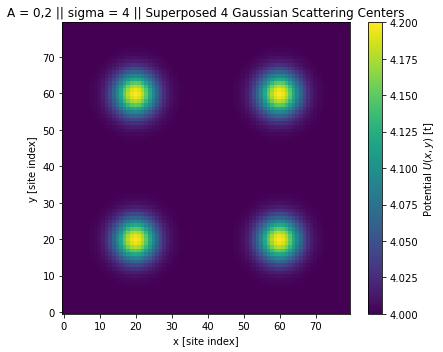

In [216]:
# Create grid
x_vals = np.arange(sys_length)
y_vals = np.arange(sys_width)
X, Y = np.meshgrid(x_vals, y_vals, indexing='ij')
U4_vals = U4_gauss(X, Y)

# Plot potential U3_gauss
plt.figure(figsize=(6, 5))
plt.pcolormesh(X, Y, U4_vals, shading='auto', cmap='viridis')
plt.colorbar(label='Potential $U(x, y)$ [t]')
plt.title('A = 0,2 || sigma = 4 || Superposed 4 Gaussian Scattering Centers')
plt.xlabel('x [site index]')
plt.ylabel('y [site index]')
plt.tight_layout()
plt.show()

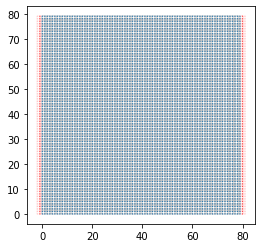

In [217]:
# Lattice
lat4_gauss = kwant.lattice.square(a, norbs=1)
# Scattering region
sys4_gauss = kwant.Builder()
sys4_gauss[(lat4_gauss(x, y) for x in range(sys_length) for y in range(sys_width))] = \
    lambda site: U4_gauss(site, site, A = 0.2, sigma = 4.0)

sys4_gauss[lat4_gauss.neighbors()] = -t

# Leads
lead4_gauss = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
lead4_gauss[(lat(0, y) for y in range(sys_width))] = 4 * t
lead4_gauss[lat4_gauss.neighbors()] = -t

sys4_gauss.attach_lead(lead4_gauss) # left lead
sys4_gauss.attach_lead(lead4_gauss.reversed()) # right lead

kwant.plot(sys4_gauss);

In [219]:
fsys4_gauss = sys4_gauss.finalized()

In [220]:
# Compute transmission U4
energies4_gauss = []
transmissions4_gauss = []
for i in range(200):
    energy4_gauss = i * 0.005
    smatrix4_gauss = kwant.smatrix(fsys4_gauss, energy4_gauss)
    energies4_gauss.append(energy4_gauss)
    transmissions4_gauss.append(smatrix4_gauss.transmission(1, 0))

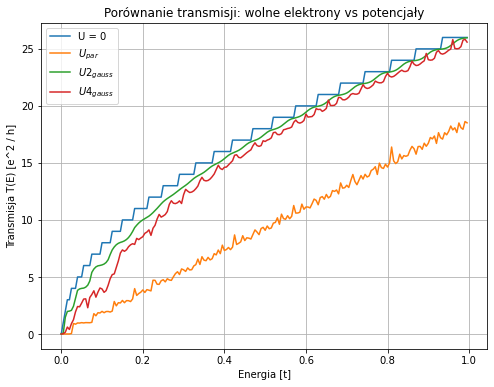

In [223]:
# Wykres porównawczy 4
plt.figure(figsize=(8, 6))
plt.plot(energies, transmission, label="U = 0")
plt.plot(energies_par, transmission_par, label="$U_{par}$")
plt.plot(energies2_gauss, transmissions2_gauss, label="$U2_{gauss}$")
plt.plot(energies4_gauss, transmissions4_gauss, label="$U4_{gauss}$")
plt.xlabel("Energia [t]")
plt.ylabel("Transmisja T(E)")
plt.title("Porównanie transmisji: wolne elektrony vs potencjały")
plt.legend()
plt.grid(True)
plt.show()

### Conclusion
The four Gaussian scatterers act like multiple barriers, causing enhanced backscattering and complex interference patterns. Transmission becomes highly energy-dependent due to the spatial distribution of scatterers.

In [224]:
def PSI4_gauss(fsys4_gauss, energy4_gauss, title):
    wf4_gauss = kwant.wave_function(fsys4_gauss, energy4_gauss)
    psi4_gauss = wf4_gauss(0)  # fala padająca z lewego leada
    psi_total = sum(np.abs(p)**2 for p in psi4_gauss)

    coords = [site.pos for site in fsys4_gauss.sites]
    x_coords, y_coords = zip(*coords)

    plt.figure(figsize=(6, 5))
    plt.tripcolor(x_coords, y_coords, psi_total, shading='gouraud',)
    plt.xlabel("x [site index]")
    plt.ylabel("y [site index]")
    plt.title(title)
    plt.colorbar(label="|ψ|²")
    plt.tight_layout()
    plt.show()

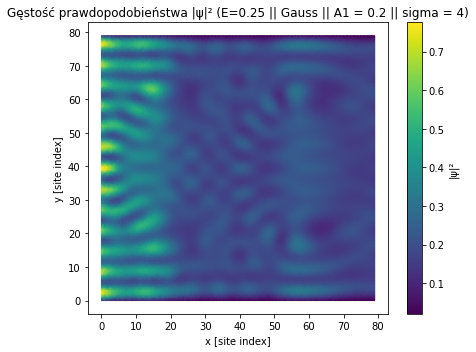

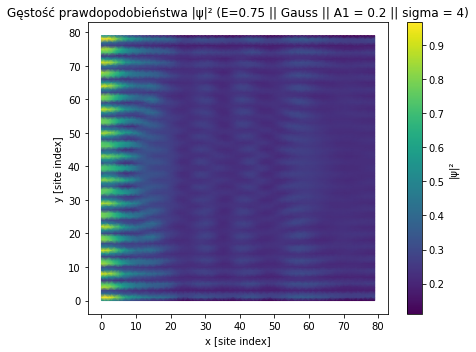

In [225]:
PSI4_gauss(fsys4_gauss, 0.25, "Gęstość prawdopodobieństwa |ψ|² (E=0.25 || Gauss || A1 = 0.2 || sigma = 4)")
PSI4_gauss(fsys4_gauss, 0.75, "Gęstość prawdopodobieństwa |ψ|² (E=0.75 || Gauss || A1 = 0.2 || sigma = 4)")

### Probability Density Conclusions
- **$U4_{gauss}$ (multiple centers)**: Strong interference patterns; electron flow splits between centers.
- The four Gaussian scatterers act like multiple barriers, causing enhanced backscattering and complex interference patterns. Transmission becomes highly energy-dependent due to the spatial distribution of scatterers.